# Studio 1 — Data ER: PPP loans in Connecticut 🏥📊

**OPIM 5641 · Business Decision Modeling · Dr. Dave Wanik, UConn**

The SBA's Paycheck Protection Program made ~11.5 million emergency loans in 2020–21, and the
loan-level data is public. This is **real data, warts and all** — missing codes, "Unanswered"
fields, suspicious job counts. Tonight we do a **Data ER**: triage first, diagnose second,
and finish with **three findings** you can defend.

*When you have data, explore it. (Next notebook: when you don't, simulate it.)*

> **The GitHub habit (do this now):** File → **Save a copy in GitHub** → pick your `opim5641-work` repo.
> Do it again at the end of the night. Open from the course repo, work, save to *your* repo — that's the loop.

## 1 · Load the data

One CSV, already filtered to Connecticut. Every column the SBA publishes is intact — including the messy ones.

> 📖 **What do all 53 columns mean?** See the [data dictionary](https://github.com/drdave-teaching/OPIM5641-notebooks/blob/main/studio1/ppp_data_dictionary.md) — official SBA descriptions plus the watch-outs (which columns lie, which are mostly “Unanswered”, and why missing ≠ zero).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

url = 'https://raw.githubusercontent.com/drdave-teaching/OPIM5641-notebooks/main/studio1/ppp_ct.csv'
df = pd.read_csv(url, low_memory=False)
print(df.shape)
df.head(3)

## 2 · Triage: what have we got?

Before any analysis: how many rows and columns, what types, and **where are the holes**?

In [ ]:
df.info(show_counts=True)

In [ ]:
# Missing-value census: which columns are mostly empty?
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0].round(3).head(15)

**Talk to your partner:** which of these missing columns would actually matter for a business question?
Is a missing `JobsReported` the same kind of problem as a missing `NAICSCode`?

## 3 · Are there duplicates?

Real datasets often have near-duplicate rows. `LoanNumber` should be unique — is it?

In [ ]:
print('rows:', len(df))
print('unique LoanNumber:', df['LoanNumber'].nunique())
# borrowers that appear more than once (many got a 1st AND 2nd draw loan — is that a duplicate?)
df['BorrowerName'].value_counts().head(10)

## 4 · Describe the money

`describe()` on the loan amounts. Then find the outliers and argue about them —
are they errors, or just the biggest employers in the state?

In [ ]:
df[['InitialApprovalAmount', 'ForgivenessAmount', 'JobsReported']].describe().round(1)

In [ ]:
# The distribution is wildly skewed — compare the raw histogram with log-scale bins
import numpy as np
amounts = df['InitialApprovalAmount'].dropna().clip(lower=100)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(amounts, bins=60)
ax[0].set_title('Loan amounts (raw) — useless!')
ax[1].hist(amounts, bins=np.logspace(2, 7, 60))
ax[1].set_xscale('log')
ax[1].set_title('Loan amounts (log-scale bins) — now we can see')
plt.tight_layout()

#### Reading the log histogram

- In studio we plotted `.apply(np.log)` — the **natural log (base e)**. On that axis, ln(dollars) reads: 10 ≈ $22k, 12 ≈ $163k, 14 ≈ $1.2M — and every **+2.3** on the axis is another **×10** in dollars.
- **Why it's easier to read:** raw loan amounts span five orders of magnitude ($hundreds to $10M), so a plain histogram is one giant bar plus an invisible tail. The log turns *ratios* into equal *distances* — it compresses the huge tail and stretches the crowded low end. What's left is roughly bell-shaped: money data is classically **log-normal**.
- **Tie to `.describe()`:** the **median $20,833** → ln ≈ 9.9 lands exactly on the peak (log keeps order, so the middle value stays the middle value). The **mean $84,260** → ln ≈ 11.3 sits well right of the peak — dragged by the multi-million-dollar loans. The unreadable raw histogram, the mean ≫ median gap, and the bell-in-logs are **the same fact three ways**: this data is right-skewed.
- The `> 0` filter is the guard rail: ln(0) = −∞ and the log of a negative number is undefined.

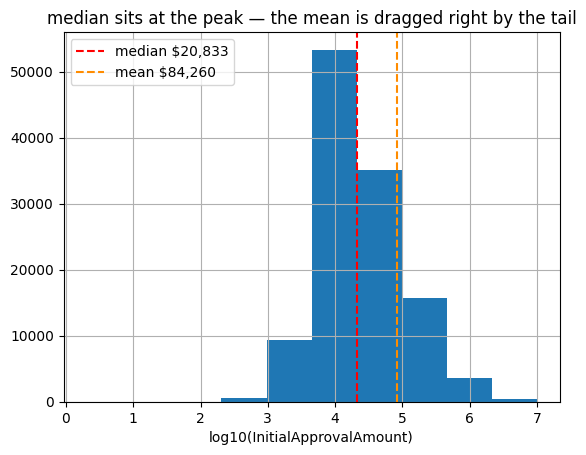

In [ ]:
# BONUS · same histogram in base 10 — ticks read directly as dollars
# 3 = $1k · 4 = $10k · 5 = $100k · 6 = $1M
amt = df[df['InitialApprovalAmount'] > 0]['InitialApprovalAmount']
amt.apply(np.log10).hist()
plt.axvline(np.log10(amt.median()), color='red', linestyle='dashed', label=f'median ${amt.median():,.0f}')
plt.axvline(np.log10(amt.mean()), color='darkorange', linestyle='dashed', label=f'mean ${amt.mean():,.0f}')
plt.legend()
plt.title('median sits at the peak — the mean is dragged right by the tail')
plt.xlabel('log10(InitialApprovalAmount)');

In [ ]:
# Top 10 biggest loans — recognize any employers?
df.nlargest(10, 'InitialApprovalAmount')[['BorrowerName', 'BorrowerCity', 'InitialApprovalAmount', 'JobsReported', 'ForgivenessAmount']]

**Mean vs median time** (this is your Math Check muscle): compute both for `InitialApprovalAmount`.
Which is bigger, and what does that gap tell you about who got PPP money?

In [ ]:
print('mean:  ', round(df['InitialApprovalAmount'].mean(), 2))
print('median:', round(df['InitialApprovalAmount'].median(), 2))

## 5 · Which industries got the money?

`NAICSCode` is a 6-digit industry code — the first 2 digits give the sector. Watch how many rows we lose to missing codes.

In [ ]:
naics2_names = {
    '11': 'Agriculture', '21': 'Mining', '22': 'Utilities', '23': 'Construction',
    '31': 'Manufacturing', '32': 'Manufacturing', '33': 'Manufacturing',
    '42': 'Wholesale Trade', '44': 'Retail Trade', '45': 'Retail Trade',
    '48': 'Transportation', '49': 'Transportation', '51': 'Information',
    '52': 'Finance & Insurance', '53': 'Real Estate', '54': 'Professional Services',
    '55': 'Management', '56': 'Admin & Waste Mgmt', '61': 'Education',
    '62': 'Health Care', '71': 'Arts & Entertainment', '72': 'Accommodation & Food',
    '81': 'Other Services', '92': 'Public Admin'}

df['naics2'] = df['NAICSCode'].astype('string').str[:2]
df['sector'] = df['naics2'].map(naics2_names)
print('rows with no sector:', df['sector'].isna().sum())

sector_dollars = df.groupby('sector')['InitialApprovalAmount'].sum().sort_values(ascending=False) / 1e6
sector_dollars.head(10).plot(kind='barh', figsize=(8, 5), title='PPP dollars by sector ($ millions, CT)')
plt.gca().invert_yaxis()
plt.tight_layout()

## 6 · Where in Connecticut?

Top cities by loan count — and watch for the data dirt (same city spelled multiple ways?).

In [ ]:
df['BorrowerCity'].str.upper().str.strip().value_counts().head(15)

## 7 · The dollars-per-job question

PPP was meant to protect paychecks. So: **dollars per job reported**. What do you find at the extremes —
and do you believe the `JobsReported` column?

In [ ]:
ok = df[(df['JobsReported'] > 0) & df['InitialApprovalAmount'].notna()].copy()
ok['dollars_per_job'] = ok['InitialApprovalAmount'] / ok['JobsReported']
ok['dollars_per_job'].describe().round(0)

In [ ]:
# The suspicious end: tiny loans claiming many jobs, huge loans claiming one
ok.nlargest(5, 'dollars_per_job')[['BorrowerName', 'InitialApprovalAmount', 'JobsReported', 'dollars_per_job']]

## 8 · Your three findings 📝

With your partner, write **three findings** below. Each one = **one plot or one table + two sentences**
(what you see, and why a decision-maker should care). This is the exact shape Assignment 1 grades.

Then: File → **Save a copy in GitHub** → your `opim5641-work` repo.

### Finding 1

*(your plot/table + two sentences)*

In [ ]:
# Finding 1 code here


### Finding 2

In [ ]:
# Finding 2 code here


### Finding 3

In [ ]:
# Finding 3 code here
